Célula 1 - Importações e carregamento

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/dengue_recife.csv")

# Converter data
df['data'] = pd.to_datetime(df['data_iniSE'], unit='ms')
df = df.sort_values('data').reset_index(drop=True)

print(df.shape)
df.head()

(520, 32)


,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,...,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year,data
0,1420329600000,201501,355.0,355,355,355,1.000000,21.470116,0,2,...,56.142857,27.375115,29.857143,272,NaN,NaN,NaN,NaN,41361,2015-01-04
1,1420934400000,201502,461.0,461,461,461,1.000000,27.880910,0,4,...,57.000000,27.412264,30.000000,358,NaN,NaN,NaN,NaN,41361,2015-01-11
2,1421539200000,201503,515.0,515,515,515,1.000000,31.146788,0,4,...,56.000000,27.766705,30.428571,387,NaN,NaN,NaN,NaN,41361,2015-01-18
3,1422144000000,201504,578.0,578,578,578,0.999998,34.956978,0,4,...,53.571429,27.587357,30.428571,423,NaN,NaN,NaN,NaN,41361,2015-01-25
4,1422748800000,201505,590.0,590,590,590,0.993120,35.682728,0,4,...,56.714286,28.133641,30.571429,455,NaN,NaN,NaN,NaN,41361,2015-02-01


Célula 2 - Casos ao longo do tempo

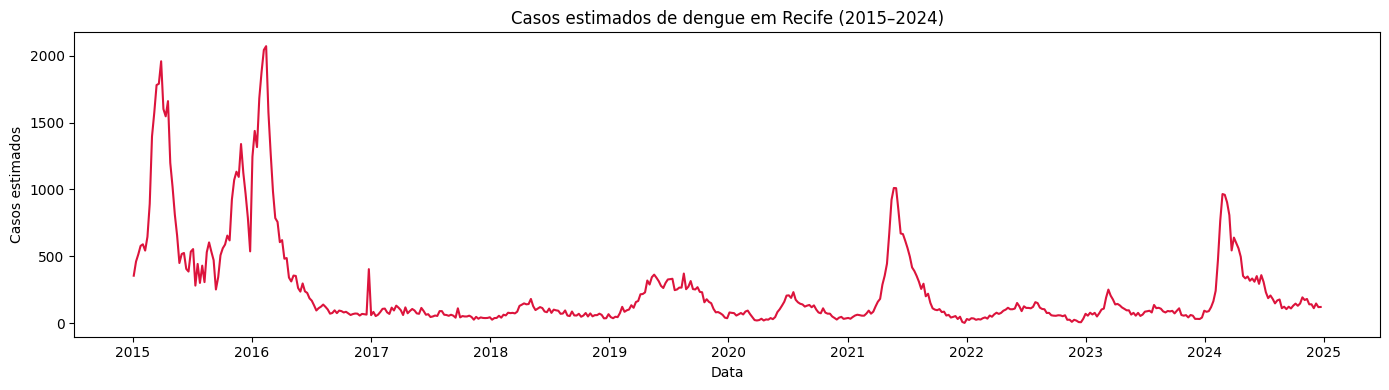

In [3]:
plt.figure(figsize=(14, 4))
plt.plot(df['data'], df['casos_est'], color='crimson', linewidth=1.5)
plt.title('Casos estimados de dengue em Recife (2015–2024)')
plt.xlabel('Data')
plt.ylabel('Casos estimados')
plt.tight_layout()
plt.savefig('../outputs/casos_ao_longo_do_tempo.png', dpi=150)
plt.show()

Célula 3 - Correlação temperatura e chuva vs casos

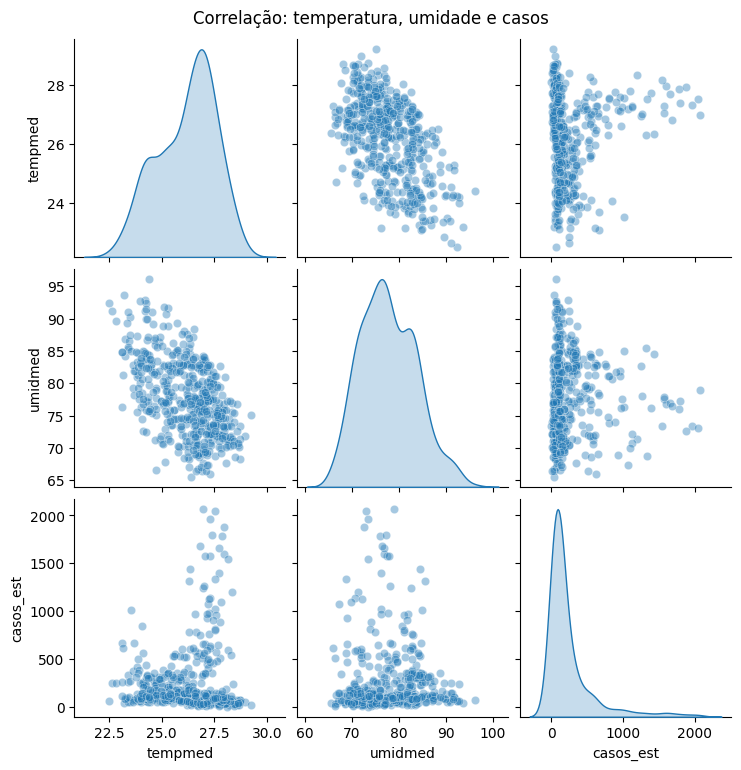

In [4]:
variaveis = ['tempmed', 'umidmed', 'casos_est']
sns.pairplot(df[variaveis].dropna(), diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Correlação: temperatura, umidade e casos', y=1.02)
plt.savefig('../outputs/correlacao.png', dpi=150)
plt.show()

Célula 4 - Nível de alerta por ano

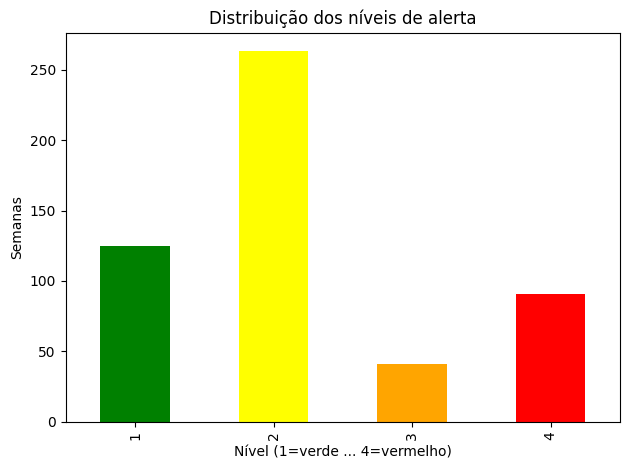

In [5]:
df['ano'] = df['data'].dt.year
df['nivel'].value_counts().sort_index().plot(
    kind='bar', color=['green','yellow','orange','red'],
    title='Distribuição dos níveis de alerta'
)
plt.xlabel('Nível (1=verde ... 4=vermelho)')
plt.ylabel('Semanas')
plt.tight_layout()
plt.savefig('../outputs/niveis_alerta.png', dpi=150)
plt.show()